# Toy model (3 reactions): COBRAk and RBA compared with GBA

Builds the toy model of the supplement (TS, AAS, R) as a COBRAk model and as an RBA model, and scans the growth rate while the proteome fraction of each enzyme is forced to values between 0 and 1. The scan is done with

* **COBRAk LP**: enzyme-constrained (kcat and MW only),
* **COBRAk NLP**: kinetic (kcat and Km, no dG0),
* **RBA**: capacity constraints, built in the way of the RiboComp model.

The GBA results are read from a file and plotted together with these three curves.

| Input | Source |
|---|---|
| Stoichiometry | Supplement, toy model: mass fraction matrix (TS: Cext -> S, AAS: S -> AA, R: AA -> P) |
| kcat | Supplement, toy model (forward values 10, 8, 4.55) |
| Km | Supplement, toy model (K matrix), used by the COBRAk NLP |
| Density, biomass composition, external carbon source | GBA result file of the toy model, at the growth optimum |

**Units.** In the COBRAk model, every toy species gets the same molar mass `M_TOY`, so the mass fraction matrix is also the molar stoichiometry (all coefficients 1). With `M_TOY` = 1000 g/mol, 1 mmol of a species is 1 g, and the default minimum concentration of COBRAk (1e-6 mol/L) is 0.001 g/L. The RBA model uses mass units (g/gDW, g/(gDW h)). The enzyme molecular weights are not used in GBA and RBA since everything is in mass fractions. In COBRAk they cancel in the conversion of the kcat values, so they do not change the results.

## 1. Imports and configuration

In [1]:
import os
import csv
import json
import time
import logging
from copy import deepcopy
from math import log

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

from cobrak.constants import ALL_OK_KEY
from cobrak.dataclasses import Enzyme, EnzymeReactionData, Metabolite, Model, Reaction, Solver
from cobrak.lps import perform_lp_optimization
from cobrak.nlps import perform_nlp_irreversible_optimization
from cobrak.standard_solvers import CPLEX

for name in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "LOKY_MAX_CPU_COUNT"):
    os.environ[name] = "16"
os.environ["PATH"] = "/home/users/dszeliova/.conda/envs/optenz/bin:" + os.environ["PATH"]

IPOPT = Solver(name="ipopt")
logging.getLogger("pyomo.core").setLevel(logging.ERROR)

In [2]:
M_TOY = 1000.0        # g/mol, molar mass of every toy species (1 mmol = 1 g)

# Molecular weight of each enzyme in kDa (1 kDa = 1000 g/mol)
ENZ_MW_KDA = {"TS": 100.0, "AAS": 400.0, "R": 826.0}

# GBA results of the toy model (one row per forced proteome fraction)
GBA_CSV = "../data/B_rev_protein_cost.csv"

REVERSIBLE_KINETICS = "_rev" in GBA_CSV  # True: products inhibit TS and AAS (K+ of the K matrix). False: irreversible
K_INF = 1e6                              # mol/L, Km of products without product inhibition (K+ -> infinity)

# Forced proteome fractions
PHI_GRID = np.linspace(0.0, 1.0, 201)
PRINT_EVERY = 10   # print the progress after every PRINT_EVERY grid points

# RBA: bisection over the growth rate
MU_SEARCH_MAX = 3.0    # 1/h, upper limit of the bisection
N_BISECTIONS = 45      # interval width 5 / 2^45
LP_OPTIONS = {"primal_feasibility_tolerance": 1e-10, "dual_feasibility_tolerance": 1e-10}

suffix = ["", "_rev"][REVERSIBLE_KINETICS]
SCAN_JSON = f"../data/toy_expression_scan_results{suffix}.json"
FIGURE_FILE = f"../figures/toy_expression_scan{suffix}.png"

## 2. Toy model data

In [3]:
# Mass fraction matrix of the toy model = molar stoichiometry (all species have the same molar mass)
stoich = {
    "TS":  {"Cext": -1.0, "S": 1.0},
    "AAS": {"S": -1.0, "AA": 1.0},
    "R":   {"AA": -1.0, "P": 1.0},
}

# Forward turnover numbers, g product / (g protein h).
KCAT_MASS = {"TS": 10.0, "AAS": 8.0, "R": 4.55}

# Km matrix (g/L). Substrates: K-. Products: K+.
K_GL = {
    "TS":  {"Cext": 10.0, "S": 30.0},
    "AAS": {"S": 10.0, "AA": 24.0},
    "R":   {"AA": 8.0},
}
IRREVERSIBLE = ["R"]            # the ribosome reaction is always irreversible
if not REVERSIBLE_KINETICS:
    IRREVERSIBLE = ["TS", "AAS", "R"]

# GBA results
with open(GBA_CSV) as f:
    gba_rows = list(csv.DictReader(f))
gba_reaction = np.array([row["reaction"] for row in gba_rows])
gba = {key: np.array([float(row[key]) for row in gba_rows]) for key in gba_rows[0] if key != "reaction"}

# Conditions of the GBA simulation at the growth optimum (the row with the highest growth rate)
i_opt = int(np.argmax(gba["mu"]))
gba_optimum_conc = {m: gba[f"c.{m}"][i_opt] for m in ("S", "AA", "P")}   # g/L
RHO_TOY = sum(gba_optimum_conc.values())                                   # g/L, cell density
A_CEXT_GL = gba["c.x_S"][i_opt]                                            # g/L, external carbon source
biomass_fraction = {m: c / RHO_TOY for m, c in gba_optimum_conc.items()}   # g/gDW

print(f"GBA optimum: growth rate {gba['mu'][i_opt]:.4f} 1/h, density {RHO_TOY:.1f} g/L, external carbon source {A_CEXT_GL:.0f} g/L")
print("biomass fractions:", {m: round(float(f), 4) for m, f in biomass_fraction.items()})

GBA optimum: growth rate 1.5170 1/h, density 340.0 g/L, external carbon source 100 g/L
biomass fractions: {'S': 0.1504, 'AA': 0.0725, 'P': 0.777}


## 3. COBRAk model

* `kcat_molar [1/h] = kcat_mass * MW_enzyme * 1000 / m_l`, with `m_l` the mass of one mole of the reaction (`M_TOY` here).
* `Km [mol/L] = Km [g/L] / M_TOY`.
* The biomass reaction consumes the biomass composition in mmol/gDW, so its flux is the growth rate. The metabolite pools S and AA are part of it because growth dilutes them.
* The enzyme pool is the protein fraction of the biomass.
* Concentration bounds (mol/L): the minimum is the default of COBRAk. The maximum is the concentration of the species in the biomass (density times fraction), but not below the default maximum of COBRAk (0.02 mol/L). The external carbon source is fixed to the value of the GBA simulation.

In [4]:
reaction_mass = M_TOY   # g/mol, one mole of every toy reaction (all coefficients are 1)

enzymes = {f"E_{r}": Enzyme(molecular_weight=ENZ_MW_KDA[r], name=f"{r} protein") for r in stoich}

reactions = {}
for r, st in stoich.items():
    kcat_molar = KCAT_MASS[r] * ENZ_MW_KDA[r] * 1000.0 / reaction_mass
    k_ms = {m: K_GL[r][m] / M_TOY for m in K_GL[r]}
    if r in IRREVERSIBLE:
        for m, coefficient in st.items():
            if coefficient > 0:
                k_ms[m] = K_INF
    reactions[r] = Reaction(
        stoichiometries=st,
        min_flux=0.0,
        max_flux=1000.0,
        enzyme_reaction_data=EnzymeReactionData(identifiers=[f"E_{r}"], k_cat=kcat_molar, k_ms=k_ms),
        name=r,
    )

reactions["EX_Cext"] = Reaction(stoichiometries={"Cext": +1.0}, max_flux=1000.0, name="Carbon source supply")
reactions["Biomass"] = Reaction(
    stoichiometries={m: -1000.0 * f / M_TOY for m, f in biomass_fraction.items()},
    max_flux=10.0,
    name="Biomass",
)

default_log_max_conc = Metabolite(name="default").log_max_conc
metabolites = {}
for m in ["S", "AA", "P"]:
    c_biomass = RHO_TOY * biomass_fraction[m] / M_TOY   # mol/L
    metabolites[m] = Metabolite(name=m, log_max_conc=max(default_log_max_conc, log(c_biomass)))
c_cext = A_CEXT_GL / M_TOY   # mol/L
metabolites["Cext"] = Metabolite(name="Cext", log_min_conc=log(c_cext), log_max_conc=log(c_cext))

model = Model(
    metabolites=metabolites,
    reactions=reactions,
    enzymes=enzymes,
    max_prot_pool=biomass_fraction["P"],
)

for r, reaction in model.reactions.items():
    left = [f"{abs(v):.3g} {m}" for m, v in reaction.stoichiometries.items() if v < 0]
    right = [f"{v:.3g} {m}" for m, v in reaction.stoichiometries.items() if v > 0]
    print(f"{r:8s} {' + '.join(left)} -> {' + '.join(right)}")
for r in stoich:
    print(f"{r:4s} kcat = {model.reactions[r].enzyme_reaction_data.k_cat:10.1f} 1/h")

# Mass balance: 0 for the internal reactions, 1000 mg per gDW for the biomass reaction
for r in stoich:
    assert abs(sum(stoich[r].values())) < 1e-12, r
assert abs(sum(v * M_TOY for v in model.reactions["Biomass"].stoichiometries.values()) + 1000.0) < 1e-6

TS       1 Cext -> 1 S
AAS      1 S -> 1 AA
R        1 AA -> 1 P
EX_Cext   -> 1 Cext
Biomass  0.15 S + 0.0725 AA + 0.777 P -> 
TS   kcat =     1000.0 1/h
AAS  kcat =     3200.0 1/h
R    kcat =     3758.3 1/h


In [5]:
ec_result = perform_lp_optimization(
    model,
    objective_target="Biomass",
    objective_sense=+1,
    with_enzyme_constraints=True,
    solver=CPLEX,
)
print("COBRAk LP growth rate:", round(ec_result["Biomass"], 4), "1/h")

variability_dict = {r: (0.0, reaction.max_flux) for r, reaction in model.reactions.items()}
nlp_result = perform_nlp_irreversible_optimization(
    model,
    objective_target="Biomass",
    objective_sense=+1,
    variability_dict=variability_dict,
    with_kappa=True,
    with_gamma=False,
    with_iota=False,
    with_alpha=False,
    solver=IPOPT,
)
print("COBRAk NLP growth rate:", round(nlp_result["Biomass"], 4), "1/h")

COBRAk LP growth rate: 2.0612 1/h
COBRAk NLP growth rate: 1.5496 1/h


## 4. RBA model
Model built analogously to Szeliova et al. 2024 (https://doi.org/10.1038/s42003-024-05815-4).

* **Metabolite rows** (equalities): the metabolite is produced by one reaction, and consumed by the next reaction, by protein synthesis, and by the growth dilution of its pool (`mu` times the pool, in the constant column `C`). One gram of amino acid gives one gram of protein.
* **Capacity rows**: `mu*v <= kcat*w`, because the enzyme concentration is `c = w / mu`. The slack variable lets the capacity be larger than needed.
* **Ribosome row**: the ribosome makes all proteins, including itself: `kR*w_R >= mu*(wTS + wAAS + wR)`.
* **Dry mass row**: all mass enters as carbon, `vTS = mu`.
* **Forced protein fraction** (optional row): the fraction of enzyme `j` in the total protein is `w_j / sum(w)`.

The highest growth rate with a feasible vector is found by bisection over `mu`.

In [6]:
pools = {"S": biomass_fraction["S"], "AA": biomass_fraction["AA"]}   # g/gDW
columns_uc = ["vTS", "vAAS", "wTS", "wAAS", "wR"]
rows_uc = ["S", "AA", "TS", "AAS", "R"]
columns_c = columns_uc + ["s_capTS", "s_capAAS", "s_capR", "C"]
rows_c = ["S", "AA", "capTS", "capAAS", "capR", "mass"]


def make_matrix_uc():
    """Stoichiometric matrix with a row for each metabolite and each enzyme."""
    return np.array([
        # vTS vAAS wTS wAAS wR
        [1, -1,  0,  0,  0],    # S:   made by TS, used by AAS
        [0,  1, -1, -1, -1],    # AA:  made by AAS, used for the synthesis of all proteins
        [0,  0,  1,  0,  0],    # TS:  made by wTS (concentration = wTS / mu)
        [0,  0,  0,  1,  0],    # AAS
        [0,  0,  0,  0,  1],    # R
    ], dtype=float)


def make_matrix_c(mu, forced=None):
    """
    Matrix of all constraints at growth rate mu (equalities, with slack columns).
    forced = (enzyme, fraction): adds a row that fixes the fraction of the enzyme in the total protein.
    """
    kts, kaas, kr = KCAT_MASS["TS"], KCAT_MASS["AAS"], KCAT_MASS["R"]
    matrix = np.array([
        # vTS  vAAS   wTS    wAAS    wR        s_TS s_AAS s_R   C
        [ 1,   -1,     0,     0,      0,        0,   0,    0,   -mu * pools["S"]],    # S
        [ 0,    1,    -1,    -1,     -1,        0,   0,    0,   -mu * pools["AA"]],   # AA
        [-mu,   0,    kts,    0,      0,       -1,   0,    0,    0],                   # capTS:  mu*vTS <= kTS*wTS
        [ 0,  -mu,     0,   kaas,     0,        0,  -1,    0,    0],                   # capAAS: mu*vAAS <= kAAS*wAAS
        [ 0,    0,   -mu,    -mu,   kr - mu,    0,   0,   -1,    0],                   # capR:   mu*sum(w) <= kR*wR
        [-1,    0,     0,     0,      0,        0,   0,    0,    mu],                  # mass:   vTS = mu
    ], dtype=float)
    if forced is not None:
        enzyme, fraction = forced
        row = np.zeros(matrix.shape[1])
        for name in stoich:
            row[columns_c.index(f"w{name}")] = -fraction
        row[columns_c.index(f"w{enzyme}")] += 1.0
        matrix = np.vstack([matrix, row])
    return matrix


def print_matrix(matrix, row_names, column_names):
    print(" " * 9 + "".join(f"{c:>9s}" for c in column_names))
    for name, row in zip(row_names, matrix):
        print(f"{name:9s}" + "".join(f"{x:9.3g}" for x in row))


def feasible(mu, forced=None):
    """True if a feasible vector exists at growth rate mu."""
    matrix = make_matrix_c(mu, forced)
    a_eq = matrix[:, :-1]
    b_eq = -matrix[:, -1]          # column C is 1
    result = linprog(c=np.zeros(a_eq.shape[1]), A_eq=a_eq, b_eq=b_eq,
                     bounds=(0, None), method="highs", options=LP_OPTIONS)
    return result.status == 0


def bisection_search_mu(forced=None):
    """Highest growth rate at which a feasible vector exists."""
    if feasible(MU_SEARCH_MAX, forced):
        raise ValueError("MU_SEARCH_MAX is feasible; increase it")
    left, right = 0.0, MU_SEARCH_MAX
    for _ in range(N_BISECTIONS):
        middle = 0.5 * (left + right)
        if middle > 0 and feasible(middle, forced):
            left = middle
        else:
            right = middle
    return left


print("matrix_uc")
print_matrix(make_matrix_uc(), rows_uc, columns_uc)
print()
print("matrix_c at mu = 1 1/h")
print_matrix(make_matrix_c(1.0), rows_c, columns_c)

mu_max_rba = bisection_search_mu()
print(f"\nRBA growth rate: {mu_max_rba:.4f} 1/h")

matrix_uc
               vTS     vAAS      wTS     wAAS       wR
S                1       -1        0        0        0
AA               0        1       -1       -1       -1
TS               0        0        1        0        0
AAS              0        0        0        1        0
R                0        0        0        0        1

matrix_c at mu = 1 1/h
               vTS     vAAS      wTS     wAAS       wR  s_capTS s_capAAS   s_capR        C
S                1       -1        0        0        0        0        0        0    -0.15
AA               0        1       -1       -1       -1        0        0        0  -0.0725
capTS           -1        0       10        0        0       -1        0        0        0
capAAS           0       -1        0        8        0        0       -1        0        0
capR             0        0       -1       -1     3.55        0        0       -1        0
mass            -1        0        0        0        0        0        0        0        1

## 5. Forced under- and overexpression

For each enzyme, its fraction `phi` of the total protein (the enzyme pool in COBRAk) is fixed. All other enzymes and fluxes are free, and the growth rate is maximized with the three methods. At `phi = 0` and `phi = 1` the growth rate is 0 (the reaction is essential, or no other enzyme is left), so these two points are set without solving. Points where IPOPT does not converge are stored as `None` and left out of the plot.

In [7]:
def model_with_forced_enzyme(base_model, reac_id, phi):
    forced_model = deepcopy(base_model)
    enzyme = forced_model.enzymes[f"E_{reac_id}"]
    concentration = phi * forced_model.max_prot_pool / enzyme.molecular_weight   # mmol/gDW
    enzyme.min_conc = concentration
    enzyme.max_conc = concentration * (1+1e-6)
    return forced_model


scan = {r: {"phi": [], "linear": [], "nonlinear": [], "rba": []} for r in stoich}
failed_points = []
n_points = len(PHI_GRID)
start_time = time.perf_counter()

for enzyme_index, r in enumerate(stoich, start=1):
    print(f"[{enzyme_index}/{len(stoich)}] enzyme {r}: {n_points} grid points", flush=True)
    for point_index, phi in enumerate(PHI_GRID, start=1):
        phi = float(phi)
        if phi <= 0.0 or phi >= 1.0:
            mu_linear = mu_nonlinear = mu_rba = 0.0
        else:
            forced_model = model_with_forced_enzyme(model, r, phi)
            mu_linear = perform_lp_optimization(
                forced_model,
                objective_target="Biomass",
                objective_sense=+1,
                with_enzyme_constraints=True,
                solver=CPLEX,
            )["Biomass"]

            mu_nonlinear = None
            try:
                scan_result = perform_nlp_irreversible_optimization(
                    forced_model,
                    objective_target="Biomass",
                    objective_sense=+1,
                    variability_dict=variability_dict,
                    with_kappa=True,
                    with_gamma=False,
                    with_iota=False,
                    with_alpha=False,
                    solver=IPOPT,
                )
                if scan_result[ALL_OK_KEY]:
                    mu_nonlinear = scan_result["Biomass"]
            except Exception:   # IPOPT can stop with an error status far from the optimum
                pass
            if mu_nonlinear is None:
                failed_points.append((r, round(phi, 5)))

            mu_rba = bisection_search_mu(forced=(r, phi))

        scan[r]["phi"].append(phi)
        scan[r]["linear"].append(mu_linear)
        scan[r]["nonlinear"].append(mu_nonlinear)
        scan[r]["rba"].append(mu_rba)
        if point_index % PRINT_EVERY == 0 or point_index == n_points:
            print(f"    * {point_index}/{n_points}, phi = {phi:.2f}, "
                  f"elapsed {time.perf_counter() - start_time:.1f} s")

with open(SCAN_JSON, "w") as f:
    json.dump(scan, f)
print("NLP points without a converged solution:", len(failed_points), failed_points)

[1/3] enzyme TS: 201 grid points
    * 10/201, phi = 0.04, elapsed 60.2 s
    * 20/201, phi = 0.10, elapsed 71.9 s
    * 30/201, phi = 0.14, elapsed 83.5 s
    * 40/201, phi = 0.20, elapsed 122.8 s
    * 50/201, phi = 0.24, elapsed 176.7 s
    * 60/201, phi = 0.29, elapsed 435.8 s
    * 70/201, phi = 0.35, elapsed 620.4 s
    * 80/201, phi = 0.40, elapsed 630.7 s
    * 90/201, phi = 0.45, elapsed 641.1 s
    * 100/201, phi = 0.49, elapsed 737.7 s
    * 110/201, phi = 0.55, elapsed 1081.2 s
    * 120/201, phi = 0.59, elapsed 1120.6 s
    * 130/201, phi = 0.65, elapsed 1165.6 s
    * 140/201, phi = 0.70, elapsed 1235.2 s
    * 150/201, phi = 0.74, elapsed 1414.2 s
    * 160/201, phi = 0.80, elapsed 1525.8 s
    * 170/201, phi = 0.84, elapsed 1536.9 s
    * 180/201, phi = 0.90, elapsed 1577.4 s
    * 190/201, phi = 0.95, elapsed 1589.1 s
    * 200/201, phi = 0.99, elapsed 1681.1 s
    * 201/201, phi = 1.00, elapsed 1681.1 s
[2/3] enzyme AAS: 201 grid points
    * 10/201, phi = 0.04, elaps

## 6. Plot

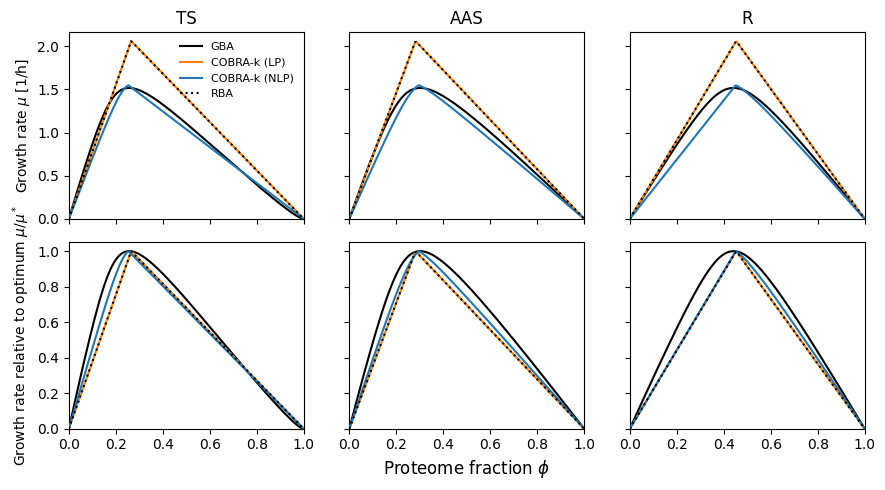

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(9, 5), sharex=True, sharey="row")
for col, r in enumerate(stoich):
    phi = np.array(scan[r]["phi"])
    linear = np.array(scan[r]["linear"], dtype=float)
    nonlinear = np.array([np.nan if v is None else v for v in scan[r]["nonlinear"]], dtype=float)
    rba = np.array(scan[r]["rba"], dtype=float)
    in_r = gba_reaction == r
    order = np.argsort(gba["phi"][in_r])
    gba_phi = gba["phi"][in_r][order]
    gba_mu = gba["mu"][in_r][order]

    # Top row: growth rate. Bottom row: growth rate relative to the optimum of each method (shape)
    top, bottom = axes[0, col], axes[1, col]
    top.plot(gba_phi, gba_mu, color="black", zorder=1, label="GBA")
    top.plot(phi, linear, color="tab:orange", zorder=2, label="COBRA-k (LP)")
    top.plot(phi, nonlinear, color="tab:blue", zorder=3, label="COBRA-k (NLP)")
    top.plot(phi, rba, color="black", linestyle=":", linewidth=1.5, zorder=4, label="RBA")
    bottom.plot(gba_phi, gba_mu / gba["mu"].max(), color="black", zorder=1)
    bottom.plot(phi, linear / ec_result["Biomass"], color="tab:orange", zorder=2)
    bottom.plot(phi, nonlinear / nlp_result["Biomass"], color="tab:blue", zorder=3)
    bottom.plot(phi, rba / mu_max_rba, color="black", linestyle=":", linewidth=1.5, zorder=4)
    top.set_title(r, fontsize=12)

axes[1, 1].set_xlabel(r"Proteome fraction $\phi$", fontsize=12)
axes[0, 0].set_ylabel(r"Growth rate $\mu$ [1/h]")
axes[1, 0].set_ylabel(r"Growth rate relative to optimum $\mu$/$\mu^*$")
axes[0, 0].legend(frameon=False, fontsize=8, loc="upper right")
for ax in axes.flat:
    ax.set_xlim(0, 1)
    ax.set_ylim(bottom=0)
fig.tight_layout()
fig.savefig(FIGURE_FILE, dpi=300)
plt.show()